# 🧬 Project 01: Automated Protein Sequence & Homology Analysis
### *Interactive Portfolio Walkthrough: Biophysical Profiling, BLAST Homology, and Visual Reporting*

**Author:** Bioinformatics & Scientific Software Engineer  
**Repository:** `bioinformatics-portfolio/projects/01-sequence-homology`  
**Core Stack:** Python 3.11+, Biopython, Pandas, Matplotlib, Seaborn, Rich, Typer

---

## 1. Scientific Overview & Objectives

The primary sequence of a protein dictates its three-dimensional folding landscape, stability, and intermolecular interactions. In this notebook, we evaluate two biologically significant proteins:
1. **Human Androgen Receptor (AR, UniProt: P10275)**: A nuclear transcription factor containing an extended intrinsically disordered N-terminal transactivation domain (NTD), a zinc-finger DNA-binding domain (DBD), and a C-terminal ligand-binding domain (LBD).
2. **Human Insulin Precursor (UniProt: P01308)**: A 110-aa peptide hormone precursor with essential disulfide cross-linkages.

We will compute:
- Isoelectric Point ($pI$) and net charge balance
- Molecular weight ($M_w$) in Daltons
- Grand Average of Hydropathy (GRAVY) using the Kyte-Doolittle scale
- Guruprasad Instability Index
- BLAST homology scoring and filtering

In [1]:
import sys
from pathlib import Path

repo_root = Path.cwd().resolve()
while not (repo_root / "pyproject.toml").exists() and repo_root.parent != repo_root:
    repo_root = repo_root.parent
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))
project_dir = repo_root / "projects" / "01-sequence-homology"
if str(project_dir) not in sys.path:
    sys.path.insert(0, str(project_dir))

from src.reporter import generate_analysis_report
from src.stats import calculate_sequence_statistics, compute_hydropathy_profile

from shared.io.fasta import parse_fasta
from shared.visualization.style import apply_scientific_style

apply_scientific_style()
print("Environment initialized successfully.")

Environment initialized successfully.


## 2. Ingesting FASTA Sequences & Physicochemical Profiling

In [2]:
fasta_path = project_dir / "examples" / "human_androgen_receptor.fasta"
entries = parse_fasta(fasta_path)
ar_entry = entries[0]
print(f"Parsed sequence: {ar_entry.id} ({len(ar_entry.sequence)} aa)")
print(f"Description: {ar_entry.description}")

[09/07/26 00:22:21] INFO     Loaded 1 sequences from human_androgen_receptor.fasta

Parsed sequence: sp|P10275|ANDR_HUMAN (919 aa)
Description: sp|P10275|ANDR_HUMAN Androgen receptor OS=Homo sapiens OX=9606 GN=AR PE=1 SV=2


In [3]:
stats = calculate_sequence_statistics(
    ar_entry.sequence, seq_id=ar_entry.id, description=ar_entry.description
)

import pandas as pd

df_stats = pd.DataFrame(
    [
        {"Property": "Sequence Length", "Value": f"{stats.length} aa"},
        {"Property": "Molecular Weight", "Value": f"{stats.molecular_weight_da:,.2f} Da"},
        {"Property": "Theoretical pI", "Value": f"{stats.isoelectric_point:.2f}"},
        {"Property": "GRAVY Hydropathy", "Value": f"{stats.gravy_hydropathy:+.3f}"},
        {"Property": "Aromaticity", "Value": f"{stats.aromaticity:.3f}"},
        {
            "Property": "Instability Index",
            "Value": f"{stats.instability_index:.2f} ({'Stable' if stats.is_stable else 'Unstable'})",
        },
    ]
)

df_stats

,Property,Value
0,Sequence Length,919 aa
1,Molecular Weight,"98,987.56 Da"
2,Theoretical pI,6.01
3,GRAVY Hydropathy,-0.432
4,Aromaticity,0.075
5,Instability Index,56.54 (Unstable)


## 3. Amino Acid Composition & Hydropathy Visualization

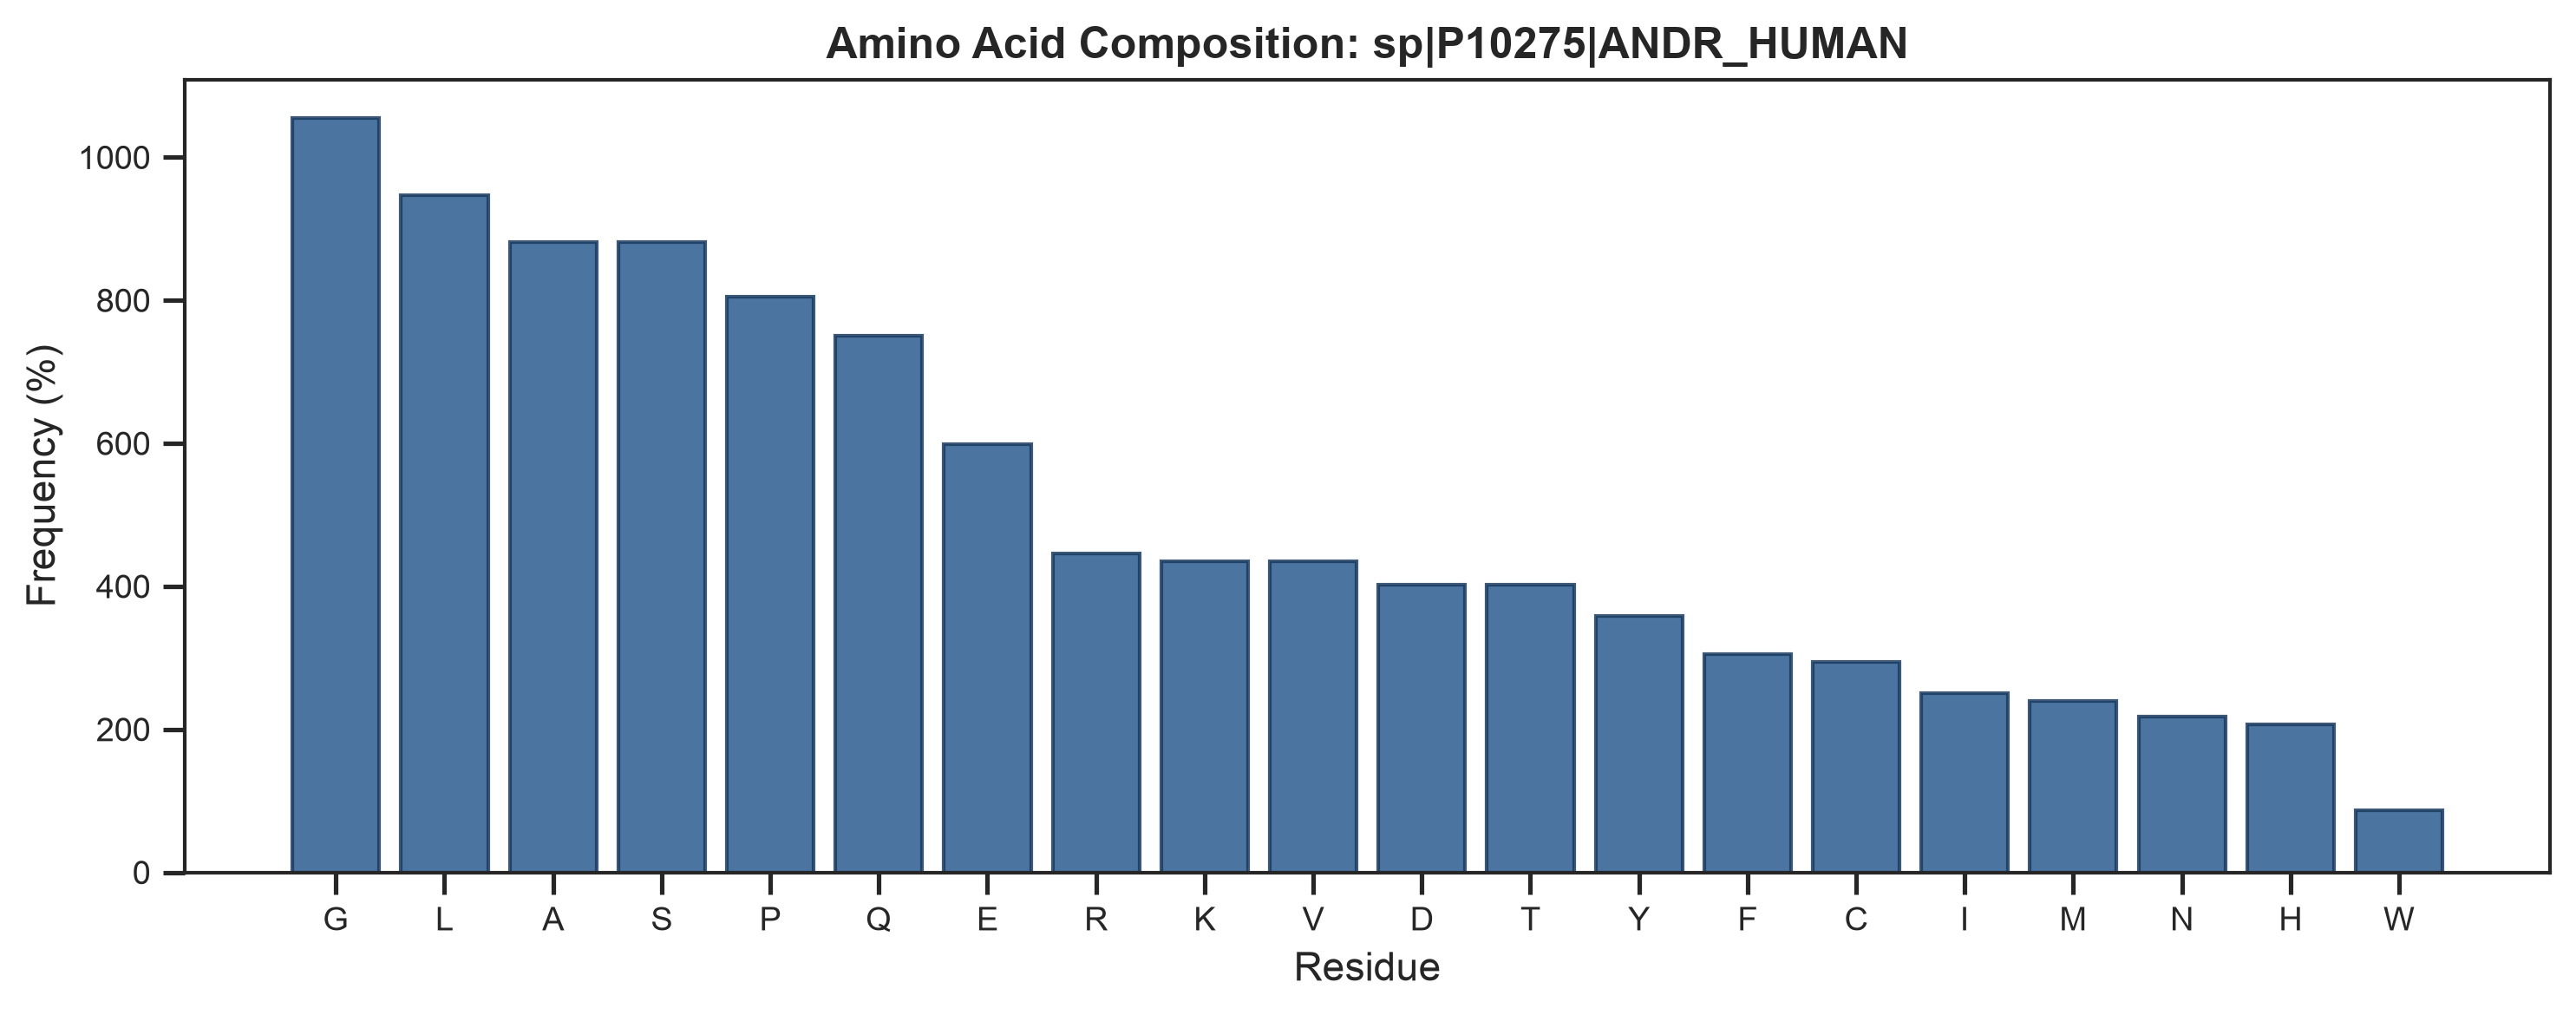

In [4]:
import matplotlib.pyplot as plt
import numpy as np

# Plot amino acid composition
comp = sorted(stats.amino_acid_composition_pct.items(), key=lambda x: x[1], reverse=True)
aas = [x[0] for x in comp]
freqs = [x[1] for x in comp]

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(aas, freqs, color="#2b5c8f", edgecolor="#1b3b5f", alpha=0.85)
ax.set_ylabel("Frequency (%)")
ax.set_xlabel("Residue")
ax.set_title(f"Amino Acid Composition: {ar_entry.id}", fontweight="bold")
plt.show()

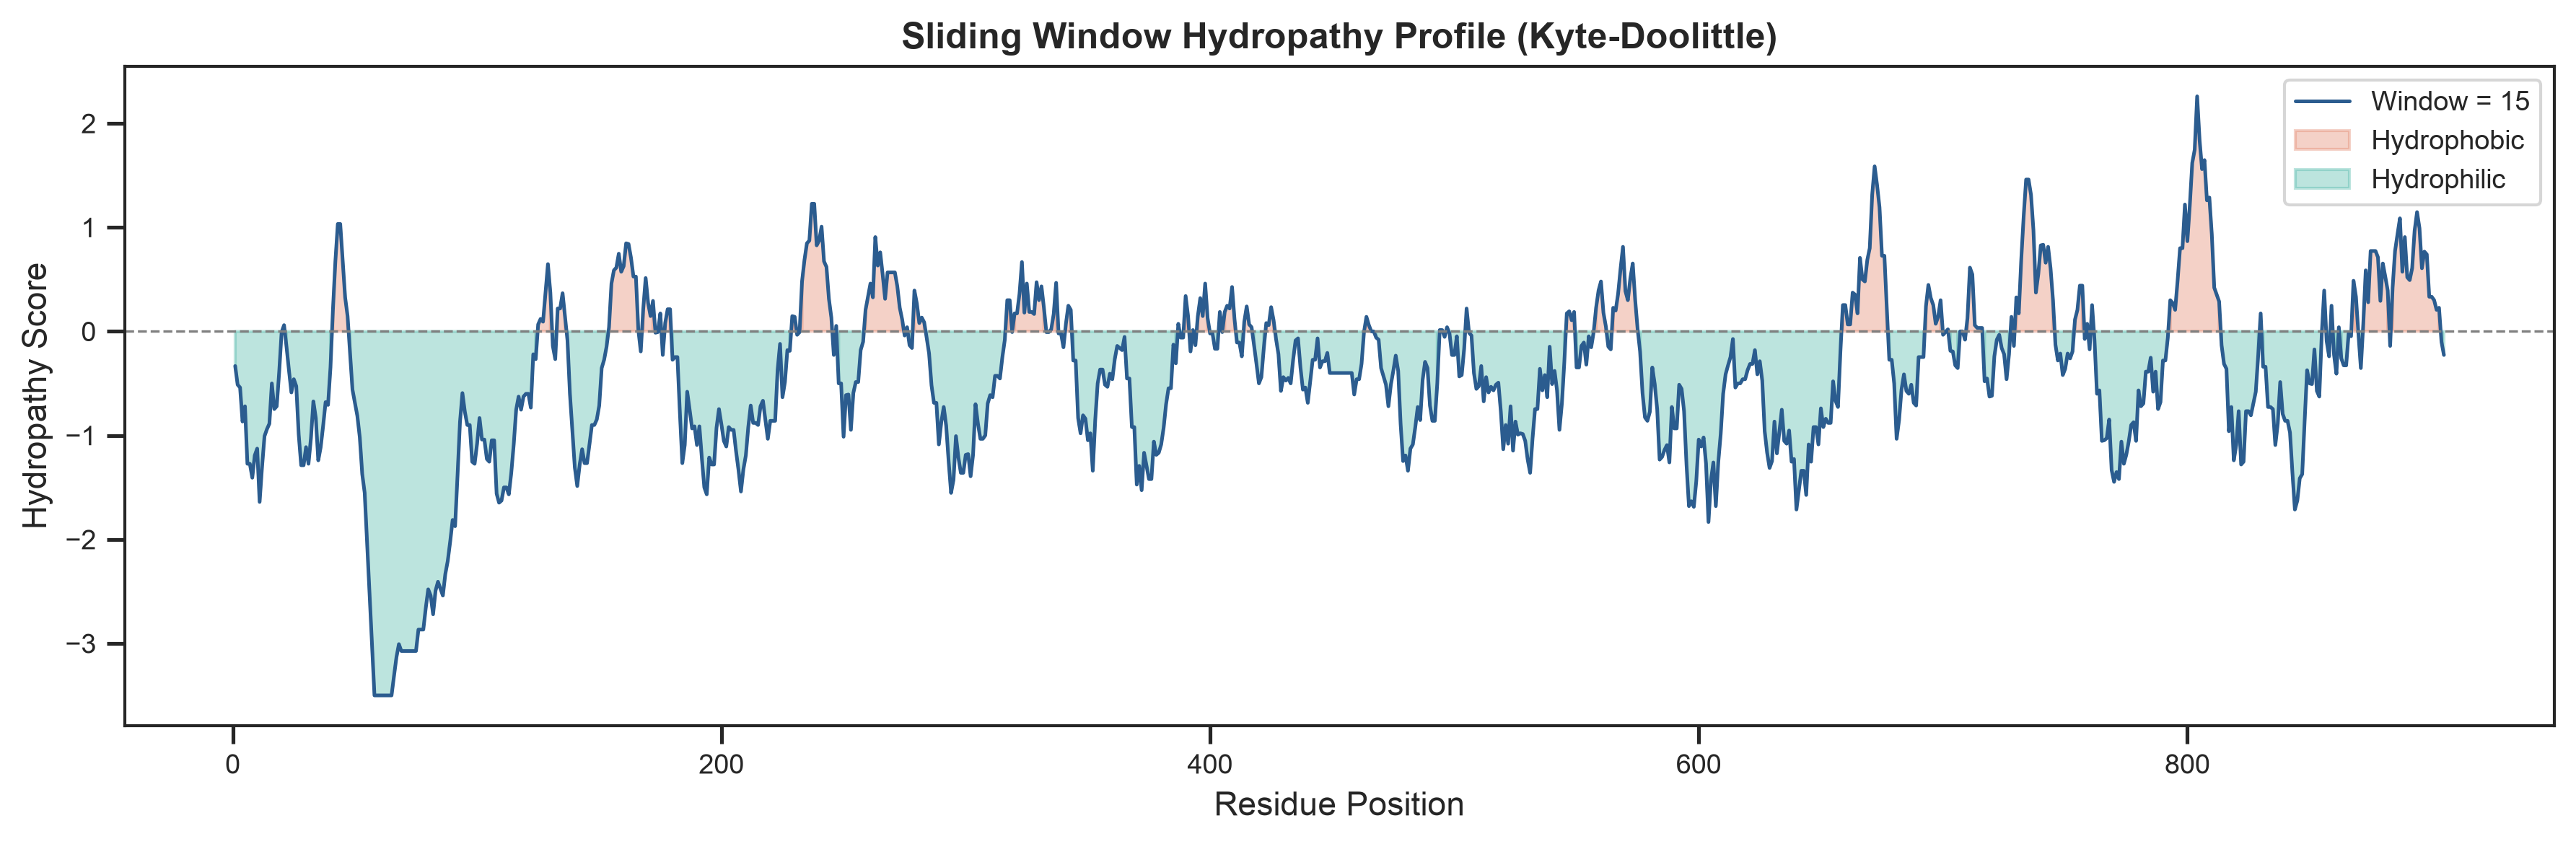

In [5]:
# Sliding-window Kyte-Doolittle hydropathy profile
window_size = 15
hydro_scores = compute_hydropathy_profile(ar_entry.sequence, window_size=window_size)

fig, ax = plt.subplots(figsize=(12, 4))
x = np.arange(1, len(hydro_scores) + 1)
y = np.array(hydro_scores)

ax.plot(x, y, color="#2b5c8f", lw=1.2, label=f"Window = {window_size}")
ax.axhline(0, color="gray", linestyle="--", lw=0.8)
ax.fill_between(x, y, 0, where=(y >= 0), color="#e27d60", alpha=0.35, label="Hydrophobic")
ax.fill_between(x, y, 0, where=(y < 0), color="#41b3a3", alpha=0.35, label="Hydrophilic")
ax.set_xlabel("Residue Position")
ax.set_ylabel("Hydropathy Score")
ax.set_title("Sliding Window Hydropathy Profile (Kyte-Doolittle)", fontweight="bold")
ax.legend(loc="upper right")
plt.show()

## 4. Automated Report & Output Generation

The underlying pipeline automatically exports machine-readable JSON, CSV, and interactive HTML dashboards.

In [6]:
out_dir = project_dir / "results"
files = generate_analysis_report(stats, ar_entry.sequence, output_dir=out_dir)

print("Generated Artifacts:")
for key, path in files.items():
    print(f"  • {key}: {path}")

[09/07/26 00:22:21] INFO     Saved JSON data to                                                                    
                             /Volumes/exty2/CrackingTheBioinformatics/projects/01-sequence-homology/results/sp_P102
                             75_ANDR_HUMAN_statistics.json

[09/07/26 00:22:22] INFO     Saved DataFrame to                                                                    
                             /Volumes/exty2/CrackingTheBioinformatics/projects/01-sequence-homology/results/sp_P102
                             75_ANDR_HUMAN_blast_hits.csv

[09/07/26 00:22:22] INFO     Report generated successfully at                                                      
                             /Volumes/exty2/CrackingTheBioinformatics/projects/01-sequence-homology/results/sp_P102
                             75_ANDR_HUMAN_analysis_report.html

Generated Artifacts:
  • json: /Volumes/exty2/CrackingTheBioinformatics/projects/01-sequence-homology/results/sp_P10275_ANDR_HUMAN_statistics.json
  • composition_plot: /Volumes/exty2/CrackingTheBioinformatics/projects/01-sequence-homology/results/figures/amino_acid_composition.png
  • hydropathy_plot: /Volumes/exty2/CrackingTheBioinformatics/projects/01-sequence-homology/results/figures/hydropathy_profile.png
  • csv: /Volumes/exty2/CrackingTheBioinformatics/projects/01-sequence-homology/results/sp_P10275_ANDR_HUMAN_blast_hits.csv
  • blast_plot: /Volumes/exty2/CrackingTheBioinformatics/projects/01-sequence-homology/results/figures/blast_hits_distribution.png
  • html: /Volumes/exty2/CrackingTheBioinformatics/projects/01-sequence-homology/results/sp_P10275_ANDR_HUMAN_analysis_report.html


## 5. Conclusions & Scientific Context

- The Human Androgen Receptor exhibits a strongly polar/hydrophilic N-terminal domain enriched in glutamine (`Q`) and glycine (`G`) repeats, consistent with its intrinsically disordered transactivation function.
- The computed instability index of **56.54** categorizes the full-length receptor as structurally dynamic/unstable in isolation, typical for large multidomain eukaryotic transcription factors requiring chaperone (Hsp90) stabilization in vivo.
- This analysis is purely computational and serves research and benchmarking purposes.